<a href="https://colab.research.google.com/github/ambika-1513/Computer-vision-learning/blob/main/capstone_sensor_fusion_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.3 MB/s eta 0:00:00


In [2]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
img = Image.open("/content/000000.png")
img_array = np.array(img)
scan = np.fromfile("/content/000000.bin" , dtype = np.float32)
points = scan.reshape(-1,4)
xyz =  points[:,:3]

In [4]:
def read_calib_file(filepath):
    calib = {}
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            key, value = line.split(':', 1)
            calib[key] = np.array([float(x) for x in value.split()])
    return calib

calib = read_calib_file("000000.txt")
P2 = calib["P2"].reshape(3, 4)
R0_rect = calib["R0_rect"].reshape(3, 3)
Tr_velo_to_cam = calib["Tr_velo_to_cam"].reshape(3, 4)

print("Image shape:", img_array.shape)
print("LiDAR points shape:", xyz.shape)
print("P2 shape:", P2.shape)
print("All data loaded successfully!")

Image shape: (370, 1224, 3)
LiDAR points shape: (115384, 3)
P2 shape: (3, 4)
All data loaded successfully!


In [5]:
model_yolo = YOLO("yolov8n.pt")

results = model_yolo(img_array, verbose=False)[0]

print(f"Detected {len(results.boxes)} objects")
for box in results.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    class_name = model_yolo.names[cls_id]
    print(f"  {class_name}: {conf:.2f}")

Detected 3 objects
  person: 0.85
  skateboard: 0.26
  bicycle: 0.26


In [6]:
CONFIDENCE_THRESHOLD = 0.5

confident_boxes = []
for box in results.boxes:
    conf = float(box.conf[0])
    if conf > CONFIDENCE_THRESHOLD:
        confident_boxes.append(box)

print(f"Confident detections (>{CONFIDENCE_THRESHOLD}): {len(confident_boxes)}")
for box in confident_boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    print(f"  {model_yolo.names[cls_id]}: {conf:.2f}")

Confident detections (>0.5): 1
  person: 0.85


In [7]:
person_box = confident_boxes[0]
x1, y1, x2, y2 = map(int, person_box.xyxy[0])

print(f"Person bounding box: x1={x1}, y1={y1}, x2={x2}, y2={y2}")

Person bounding box: x1=713, y1=150, x2=804, y2=305


In [8]:
# Full transformation chain - LiDAR to camera pixels
ones = np.ones((xyz.shape[0], 1))
points_homo = np.hstack((xyz, ones))

points_cam = Tr_velo_to_cam @ points_homo.T
points_rect = R0_rect @ points_cam

ones_rect = np.ones((1, points_rect.shape[1]))
points_rect_homo = np.vstack((points_rect, ones_rect))
points_2d_homo = P2 @ points_rect_homo

u = points_2d_homo[0, :] / points_2d_homo[2, :]
v = points_2d_homo[1, :] / points_2d_homo[2, :]
depth = points_2d_homo[2, :]

img_height, img_width = img_array.shape[:2]

valid = (depth > 0) & (u >= 0) & (u < img_width) & (v >= 0) & (v < img_height) & (~np.isnan(u)) & (~np.isnan(v))

u_valid = u[valid]
v_valid = v[valid]
depth_valid = depth[valid]

print(f"Total valid projected points: {len(u_valid)}")

Total valid projected points: 20285


In [9]:
in_box = (u_valid >= x1) & (u_valid <= x2) & (v_valid >= y1) & (v_valid <= y2)

person_points_u = u_valid[in_box]
person_points_v = v_valid[in_box]
person_depth = depth_valid[in_box]

print(f"LiDAR points falling inside person's bounding box: {len(person_depth)}")
if len(person_depth) > 0:
    print(f"Distance range: {person_depth.min():.2f}m to {person_depth.max():.2f}m")
    print(f"Median distance: {np.median(person_depth):.2f}m")

LiDAR points falling inside person's bounding box: 1323
Distance range: 8.07m to 72.73m
Median distance: 12.20m


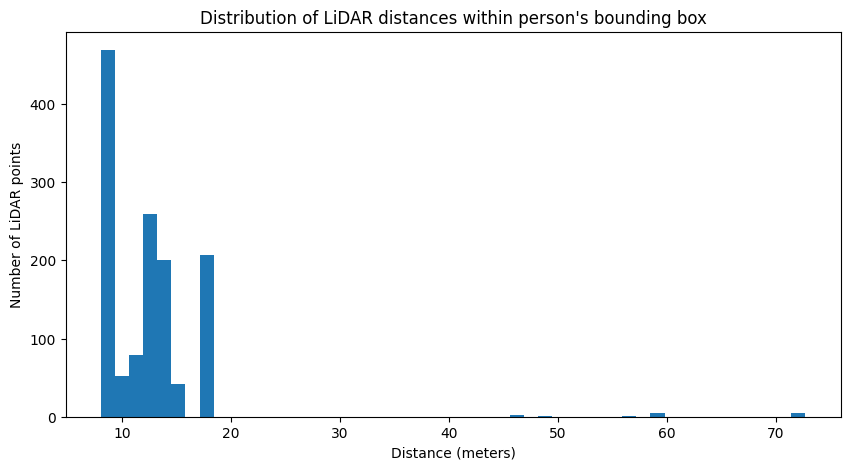

In [10]:
plt.figure(figsize=(10,5))
plt.hist(person_depth, bins=50)
plt.xlabel("Distance (meters)")
plt.ylabel("Number of LiDAR points")
plt.title("Distribution of LiDAR distances within person's bounding box")
plt.show()

In [11]:
# Remove outliers - keep only points close to the median (likely the actual person)
median_dist = np.median(person_depth)

# Keep points within 1 meter of the median (a person is roughly 0.5m thick)
distance_filter = np.abs(person_depth - median_dist) < 1.0

filtered_depth = person_depth[distance_filter]

print(f"Points before filtering: {len(person_depth)}")
print(f"Points after filtering: {len(filtered_depth)}")
print(f"Filtered distance range: {filtered_depth.min():.2f}m to {filtered_depth.max():.2f}m")
print(f"Final estimated distance to person: {np.median(filtered_depth):.2f}m")

Points before filtering: 1323
Points after filtering: 312
Filtered distance range: 11.28m to 12.82m
Final estimated distance to person: 12.28m


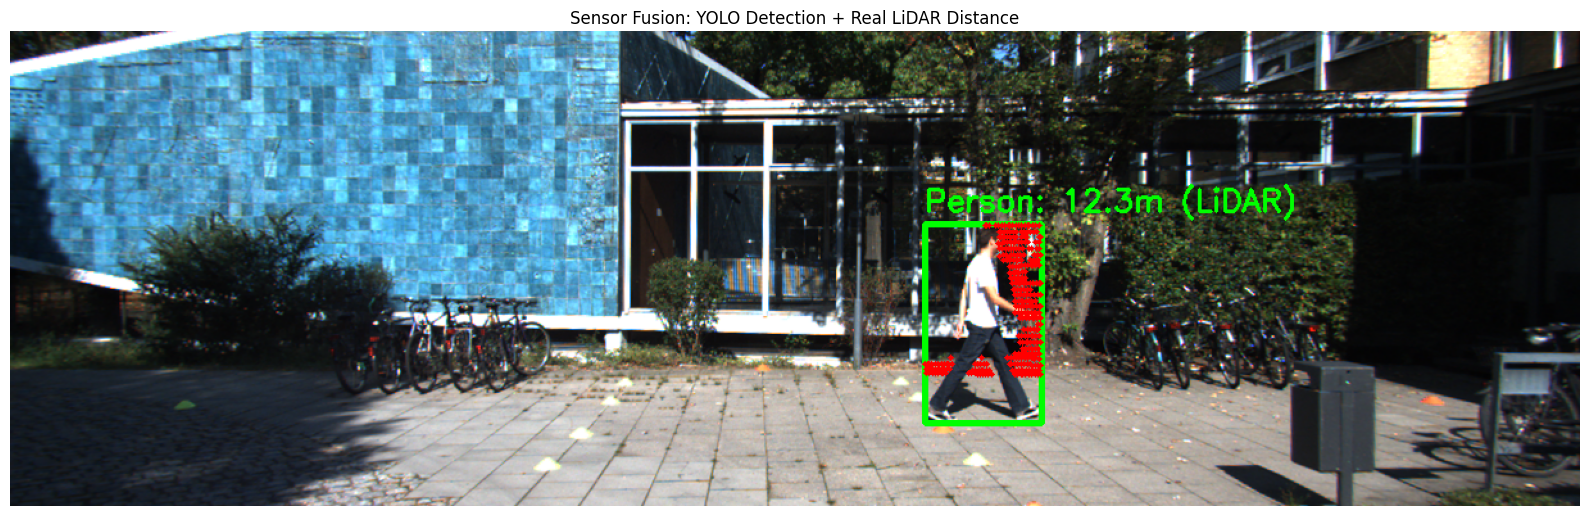

In [12]:
final_img = img_array.copy()

cv2.rectangle(final_img, (x1, y1), (x2, y2), (0, 255, 0), 3)

label = f"Person: {np.median(filtered_depth):.1f}m (LiDAR)"
cv2.putText(final_img, label, (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

person_u_filtered = person_points_u[distance_filter]
person_v_filtered = person_points_v[distance_filter]

for ui, vi in zip(person_u_filtered.astype(int), person_v_filtered.astype(int)):
    cv2.circle(final_img, (ui, vi), 2, (255, 0, 0), -1)

plt.figure(figsize=(16, 10))
plt.imshow(final_img)
plt.title("Sensor Fusion: YOLO Detection + Real LiDAR Distance")
plt.axis('off')
plt.tight_layout()
plt.show()